### 랭그래프_실습

In [2]:
from langchain_community.llms import Ollama 
from langchain_core.prompts import PromptTemplate  
from langgraph.graph import StateGraph, END 
from typing import TypedDict 

# 상태 정의
class AgentState(TypedDict):
    query: str                # 사용자 질의
    symptoms: str             # 추출된 신체 상태/증상
    exercise_candidates: str  # 추천 운동 후보 (disease -> exercise로 변경)
    result: str               # 최종 응답

# LLM 초기화
llm = Ollama(model="exaone3.5:2.4b")


# 추출 에이전트
extractor_prompt = PromptTemplate.from_template("""
사용자의 질문에서 현재 겪고 있는 신체적 증상이나 고민(예: 체력 저하, 체중 증가 등)에 해당하는 핵심 단어를 추출하세요.  
결과는 다른 설명 없이 쉼표로 구분된 단어들로만 출력하세요.  
질문: {query}
""")

def extractor_agent(state: AgentState):
    chain = extractor_prompt | llm
    symptoms = chain.invoke({"query": state["query"]})
    return {**state, "symptoms": symptoms.strip()}


# 후보 에이전트
candidate_prompt = PromptTemplate.from_template("""
다음 사용자의 신체적 증상/고민을 해결하는 데 가장 도움이 되는 운동 3가지를 추천해주세요.
다른 부가 설명 없이 쉼표로 구분된 운동 이름으로만 출력하세요.
증상: {symptoms}
""")

def candidate_agent(state: AgentState):
    chain = candidate_prompt | llm
    candidates = chain.invoke({"symptoms": state["symptoms"]})
    return {**state, "exercise_candidates": candidates.strip()}


# 답변 에이전트
answer_prompt = PromptTemplate.from_template("""
당신은 전문 헬스 트레이너입니다. 다음 정보를 바탕으로 사용자에게 알맞은 운동 계획을 설명해주세요.

- 사용자의 고민: {symptoms}
- 추천 운동 리스트: {exercise_candidates}

반드시 아래의 형식을 지켜서 '개조식(글머리 기호를 사용한 요약 형태)'으로 답변을 작성하세요:
1. 현재 상태 분석 (간단히)
2. 추천 운동 및 추천 이유 (각 운동별로)
3. 주의사항
""")

def answer_agent(state: AgentState):
    chain = answer_prompt | llm
    answer = chain.invoke({
        "symptoms": state["symptoms"],
        "exercise_candidates": state["exercise_candidates"] # 변경된 상태 키 적용
    })
    return {**state, "result": answer.strip()}


# LangGraph 정의
graph = StateGraph(AgentState)

graph.add_node("extractor", extractor_agent)
graph.add_node("candidate", candidate_agent) 
graph.add_node("answer", answer_agent)

graph.set_entry_point("extractor")
graph.add_edge("extractor", "candidate")
graph.add_edge("candidate", "answer")
graph.add_edge("answer", END)

app = graph.compile()

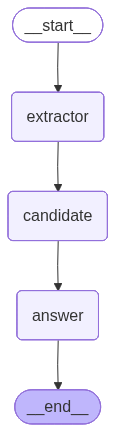

In [3]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [4]:
print("============================== LangGraph 구조:")
app.get_graph().print_ascii()

============================== LangGraph 구조:
+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
+-----------+  
| extractor |  
+-----------+  
      *        
      *        
      *        
+-----------+  
| candidate |  
+-----------+  
      *        
      *        
      *        
  +--------+   
  | answer |   
  +--------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


In [5]:
query = "체력이 안좋고, 살이 계속 찌는데 어떤 운동을 할까?"
result = app.invoke({"query": query})

print("\n============================== 최종 응답:")
print(result["result"])


============================== 최종 응답:
## 건강 개선을 위한 운동 계획 안내

**1. 현재 상태 분석**

* 체력 저하와 체중 증가는 복합적인 요인으로 작용할 수 있으며, 생활 습관, 스트레스 수준, 유전적 요인 등이 영향을 미칩니다. 개선을 위해서는 꾸준한 운동과 건강한 식단 관리가 필수적입니다.

**2. 추천 운동 및 추천 이유**

* **유산소 운동 (3회/주):**
    * **특징:** 심장 건강 증진, 체중 관리, 스트레스 해소 효과
    * **추천 예시:** 달리기, 수영, 자전거 타기 (초보자는 걷기부터 시작)
    * **이유:** 지속적인 유산소 활동은 기초대사량을 높여 칼로리 소모를 증가시키고 체중 감량에 도움을 줍니다. 스트레스 해소와 정신 건강 개선에도 효과적입니다.

* **고강도 간헐적 훈련 (2회/주):**
    * **특징:** 고강도 운동을 짧게 반복하여 심폐기능 향상, 근력 증진 효과
    * **추천 예시:** 인터벌 트레이닝 (예: 달리기 시 빠른 속도로 30초 동안 달리다가 회복 시간 90초 반복)
    * **이유:** 짧은 고강도 운동은 에너지 소비량을 극대화하여 효율적인 칼로리 소모를 이끌어내며, 근력 강화에도 효과적입니다. 체중 관리와 근육량 증가에 도움이 됩니다.

* **근력 운동 (2회/주, 각 근육군 2회씩 반복):**
    * **특징:** 근육 강화, 근력 향상, 자세 교정 효과
    * **추천 예시:**Squats (등근), Push-ups (삼두근), Pull-ups (상완근), Lunges (하체근) 등 다양한 운동
    * **이유:** 근력 운동은 기초대사량을 높여 지속적인 에너지 소비를 유도하고, 체지방 감소에 효과적입니다. 또한 부상 예방 및 건강한 자세 유지에 중요합니다.

**3. 주의사항**

* **점진적 증가:** 운동 강도와 횟수를 갑자기 높이지 않도록 주의하고, 몸의 반응을 살피세요.
* **충분한 준비운동:** 부상 예